# Data Loading & Quality Checks — Malaysian PDM dataset
### Role 1: counts per class, sizes, colour mode,
### corrupted files, duplicates, balance.

In [5]:
import os, hashlib
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

CLASSES = ["Low Potential Dysgraphia", "Potential Dysgraphia"]
BASE = "DATASET DYSGRAPHIA HANDWRITING"

In [6]:
# count images per class (balance check)
counts = {}
for cls in CLASSES:
    fs = [f for f in os.listdir(os.path.join(BASE, cls))
          if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    counts[cls] = len(fs)
print(counts, "| total:", sum(counts.values()))

{'Low Potential Dysgraphia': 135, 'Potential Dysgraphia': 114} | total: 249


In [7]:
# loop every image: size, mode, corrupted?, md5 for duplicates
rows = []
for cls in CLASSES:
    folder = os.path.join(BASE, cls)
    for f in sorted(os.listdir(folder)):
        if not f.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
        path = os.path.join(folder, f)
        try:
            with Image.open(path) as im:
                w, h = im.size
                mode = im.mode
            ok = True
        except Exception:
            w, h, mode, ok = 0, 0, "CORRUPTED", False
        md5 = hashlib.md5(open(path, "rb").read()).hexdigest()
        rows.append({"class": cls, "file": f, "width": w, "height": h,
                     "mode": mode, "ok": ok, "md5": md5})
df = pd.DataFrame(rows)
df["aspect"] = df["width"] / df["height"].clip(lower=1)

In [8]:
# the image version of shape() and describe()
print("shape:", df.shape)
print("corrupted:", df[~df.ok]["file"].tolist())
print("duplicates:", df[df.md5.duplicated()]["file"].tolist())
df[["width", "height", "aspect"]].describe()

shape: (249, 8)
corrupted: []
duplicates: []


,width,height,aspect
count,249.000000,249.000000,249.000000
mean,1090.586345,173.939759,7.041890
std,244.593197,78.864423,2.186672
min,396.000000,55.000000,3.020089
25%,918.000000,102.000000,5.306452
50%,1204.000000,164.000000,6.948980
75%,1258.000000,230.000000,8.102564
max,1434.000000,448.000000,14.238636


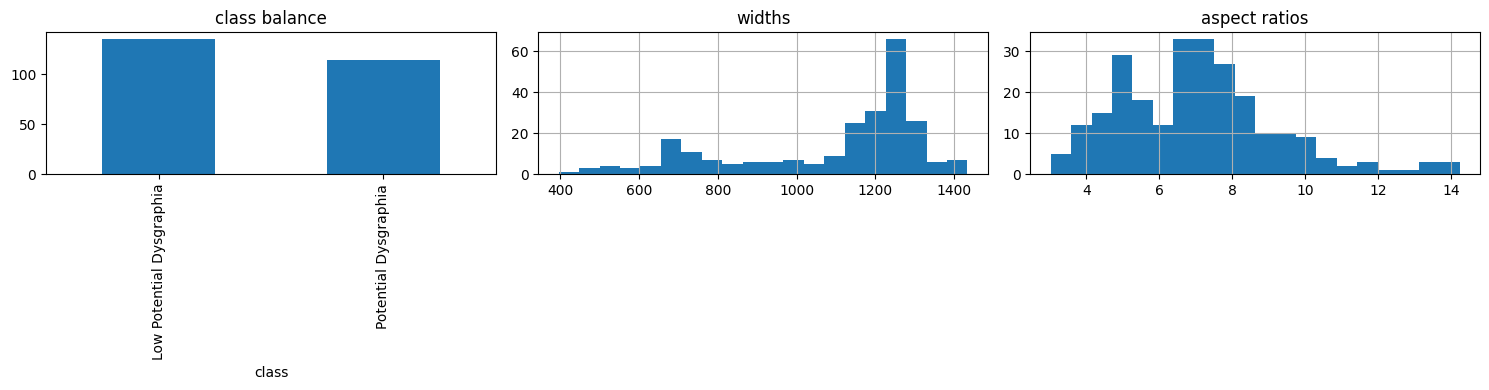

In [9]:
# balance + distributions (template asks for plots)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
df["class"].value_counts().plot.bar(ax=ax[0]); ax[0].set_title("class balance")
df["width"].hist(bins=20, ax=ax[1]); ax[1].set_title("widths")
df["aspect"].hist(bins=20, ax=ax[2]); ax[2].set_title("aspect ratios")
plt.tight_layout()
plt.show()

## Quality summary (Malaysian PDM)
- **Uniformity:** all grayscale ("L") jpgs, white ink on black background
- **Consistency:** two folders, naming style LPD/PD + number
- **Completeness:** corrupted = [] (none)
- **Accuracy:** labels come from psychologist assessment (trusted source)
- **Validity:** widths 396–1434 px, aspect 3–14 → long strips ⇒ padding needed before modeling
- **Uniqueness:** duplicates = [] (none)
- **Shape/balance:** 249 total (135 Low / 114 Potential) → mild imbalance ⇒ stratified splits

# Step 2: Image Cleaning and Preprocessing Pipeline
### Role 2: standardize colour mode, resize, deskew, crop borders,
### normalize pixel values, and set up training time augmentation.

For the screening tool to work well, every handwriting sample needs to reach the model
looking the same way, no matter how it was scanned or photographed. This section builds
the cleaning functions that take a raw image and turn it into something the CNN can use
consistently, and the augmentation step that adds controlled variation during training so
the model does not overfit to this small dataset.

In [10]:
import cv2
import numpy as np

TARGET_SIZE = (256, 256)  # width, height fed to the CNN

### Standardize colour mode
The quality check already showed every image is grayscale ("L" mode), but new uploads
through the web app could arrive as RGB photos of a page. I would convert anything that
is not already single channel down to grayscale so the pipeline behaves the same way
regardless of source.

In [11]:
def standardize_colour(img):
    # if the image has 3 channels, collapse it to one
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img

### Crop borders
Since the ink is white on a black background, anything that is close to black at the
edges is empty padding rather than handwriting. I would threshold the image, find the
bounding box of the bright pixels, and crop to that box with a small margin so no strokes
get cut off.

In [12]:
def crop_borders(img, margin=10):
    _, thresh = cv2.threshold(img, 30, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)
    if coords is None:
        return img  # blank image, nothing to crop
    x, y, w, h = cv2.boundingRect(coords)
    x0, y0 = max(x - margin, 0), max(y - margin, 0)
    x1, y1 = min(x + w + margin, img.shape[1]), min(y + h + margin, img.shape[0])
    return img[y0:y1, x0:x1]

### Deskew
A photo of a handwriting sample is rarely taken perfectly straight. I would find the
minimum-area rectangle that encloses the ink pixels, read off its rotation angle, and
rotate the image back so the writing sits level. This is a simple heuristic based on the
overall shape of the ink blob, so it works best when there is one continuous strip of
writing, which matches what the quality check found.

In [13]:
def deskew(img):
    _, thresh = cv2.threshold(img, 30, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)
    if coords is None:
        return img
    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45:
        angle = 90 + angle
    if abs(angle) < 0.5:
        return img  # already close enough to level
    h, w = img.shape
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderValue=0)

### Resize and pad
The quality summary flagged widths from 396 to 1434 pixels and aspect ratios from 3 to
14, so simply stretching every image to a square would distort the handwriting badly.
I would scale each image down so it fits inside the target size while keeping its aspect
ratio, then pad the leftover space with black, which matches the background colour
already used in these scans.

In [14]:
def resize_and_pad(img, target_size=TARGET_SIZE):
    h, w = img.shape
    target_w, target_h = target_size
    scale = min(target_w / w, target_h / h)
    new_w, new_h = int(w * scale), int(h * scale)
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    canvas = np.zeros((target_h, target_w), dtype=np.uint8)
    x_off = (target_w - new_w) // 2
    y_off = (target_h - new_h) // 2
    canvas[y_off:y_off + new_h, x_off:x_off + new_w] = resized
    return canvas

### Normalize pixel values
I would scale pixel values from the 0 to 255 range down to 0 to 1, which is the standard
input range for a CNN and helps training converge more smoothly.

In [15]:
def normalize(img):
    return img.astype("float32") / 255.0

### Full pipeline and a quick check
I would chain the steps above into one function, then run it on a sample image to make
sure everything works end to end before applying it across the whole dataset.

In [16]:
def preprocess_image(path, target_size=TARGET_SIZE):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    img = standardize_colour(img)
    img = crop_borders(img)
    img = deskew(img)
    img = resize_and_pad(img, target_size)
    img = normalize(img)
    return img

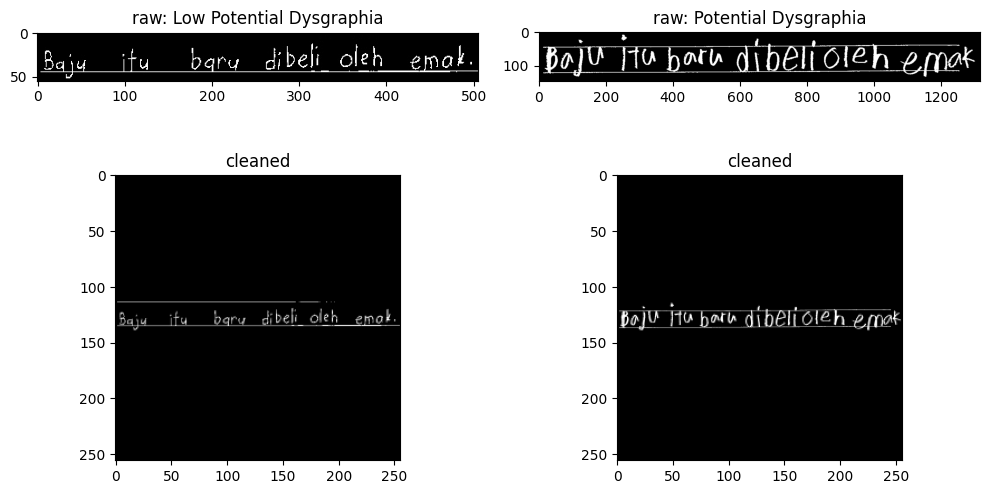

In [17]:
# pick one sample from each class and show it before and after cleaning
sample_paths = [os.path.join(BASE, cls, os.listdir(os.path.join(BASE, cls))[0]) for cls in CLASSES]

fig, ax = plt.subplots(2, 2, figsize=(10, 6))
for i, path in enumerate(sample_paths):
    raw = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    clean = preprocess_image(path)
    ax[0, i].imshow(raw, cmap="gray"); ax[0, i].set_title(f"raw: {CLASSES[i]}")
    ax[1, i].imshow(clean, cmap="gray"); ax[1, i].set_title("cleaned")
plt.tight_layout()
plt.show()

### Augmentation for training
The dataset only has 249 images total, which is small for a CNN, so I would add
augmentation that only runs during training, never on validation or test data. Rotation,
zoom, and brightness jitter give the model some natural variation to learn from without
changing what the handwriting actually says. I would keep the ranges modest since these
are scanned strips rather than natural photos, a large rotation or zoom could crop out
part of the writing.

In [18]:
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.03),      # small angle, keeps strokes readable
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.15),
])

In [19]:
# augmentation only activates when training=True, so it is safe to plug this layer
# straight into the start of the model, or map it over a tf.data training set:
# train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

## Preprocessing summary (Malaysian PDM)
We built a cleaning pipeline that takes a raw handwriting scan, makes sure it is
grayscale, crops away the empty black padding, straightens out any tilt, resizes it to a
fixed 256 by 256 shape while keeping the original proportions, and scales the pixel
values to a 0 to 1 range. On top of that, we set up rotation, zoom, and brightness jitter
as training only augmentation to help the model generalize better given how small this
dataset is. The deskew step is a simple heuristic based on the ink bounding box, so it
may not fully correct samples with unusual shapes or more than one block of writing, and
we would flag that as something to check visually rather than assume it always works
perfectly.

# Step 3: Interpretable Indicator Feature Engineering
### Role 3: connected component analysis for the spacing consistency score,
### and line fitting for the baseline deviation score, run on the cleaned images
### from Step 2.

A CNN score alone would not be convincing enough for a screening tool like this,
since teachers and parents need to understand why a sample was flagged. I would build two
simple, explainable numbers alongside the CNN prediction: how consistent the spacing
between strokes is, and how much the writing wanders off a straight line. Both are
patterns that occupational therapy literature links to handwriting difficulty, and both
can be explained in plain language to a parent.

In [20]:
# reuses the cleaning pipeline from Step 2
def binarize(clean_img):
    img8 = (clean_img * 255).astype("uint8")
    _, binary = cv2.threshold(img8, 30, 255, cv2.THRESH_BINARY)
    return binary

### Splitting the image into lines
Most samples have two or three lines of writing, so I would first work out where each
line sits before measuring anything. I would sum up the bright pixels across each row,
since a row that cuts through a line of writing will have a high sum and a row between
lines will be close to zero, and group the rows with ink into line bands.

In [21]:
def segment_lines(binary, min_gap=2, min_line_height=4):
    row_sums = binary.sum(axis=1)
    has_ink = row_sums > 0
    lines = []
    start = None
    gap = 0
    for i, ink in enumerate(has_ink):
        if ink:
            if start is None:
                start = i
            gap = 0
        else:
            if start is not None:
                gap += 1
                if gap > min_gap:
                    end = i - gap
                    if end - start >= min_line_height:
                        lines.append((start, end))
                    start = None
    if start is not None:
        end = len(has_ink) - 1
        if end - start >= min_line_height:
            lines.append((start, end))
    return lines

### Spacing consistency score
Within each line, I would use connected component analysis to find every separate stroke
or letter, then measure the horizontal gap between neighbouring strokes. A child with
typical spacing tends to leave fairly even gaps, while a child who struggles with motor
planning often leaves gaps that swing between cramped and overly wide. I would summarise
that swing with the coefficient of variation, the standard deviation of the gaps divided
by their mean, since it stays comparable even when overall writing size differs from
child to child. A higher score means less consistent spacing.

In [22]:
def spacing_consistency_score(binary):
    lines = segment_lines(binary)
    line_cvs = []
    for y0, y1 in lines:
        band = binary[y0:y1, :]
        _, _, stats, _ = cv2.connectedComponentsWithStats(band, connectivity=8)
        comps = stats[1:]  # drop the background label
        if len(comps) < 3:
            continue  # too few strokes on this line to measure spacing meaningfully
        comps = comps[np.argsort(comps[:, 0])]  # left to right
        gaps = []
        for i in range(len(comps) - 1):
            x_left, w_left = comps[i, 0], comps[i, 2]
            x_right = comps[i + 1, 0]
            gap = x_right - (x_left + w_left)
            if gap > 0:
                gaps.append(gap)
        if len(gaps) >= 2:
            gaps = np.array(gaps, dtype="float32")
            line_cvs.append(gaps.std() / (gaps.mean() + 1e-6))
    return float(np.mean(line_cvs)) if line_cvs else np.nan

### Baseline deviation score
For the same lines, I would take the bottom edge of each stroke as a rough baseline
point, fit a straight line through those points with a first degree polynomial fit, and
measure how far the actual points stray from that fitted line using root mean squared
error. Writing that sits neatly on an invisible baseline gives a low score, while writing
that drifts up and down across the line gives a higher one.

In [23]:
def baseline_deviation_score(binary):
    lines = segment_lines(binary)
    line_rmses = []
    for y0, y1 in lines:
        band = binary[y0:y1, :]
        _, _, stats, _ = cv2.connectedComponentsWithStats(band, connectivity=8)
        comps = stats[1:]
        if len(comps) < 3:
            continue
        x_centres = comps[:, 0] + comps[:, 2] / 2
        baselines = comps[:, 1] + comps[:, 3]  # bottom edge of each stroke
        coeffs = np.polyfit(x_centres, baselines, deg=1)
        fitted = np.polyval(coeffs, x_centres)
        residuals = baselines - fitted
        line_rmses.append(np.sqrt(np.mean(residuals ** 2)))
    return float(np.mean(line_rmses)) if line_rmses else np.nan

### Putting the indicators together and checking them across the dataset
I would wrap both scores into one function that takes a raw image path, runs it through
Step 2's cleaning pipeline, and returns both indicators. Then I would run it across the
whole dataset and compare the two classes, mainly to sanity check that the scores move in
a sensible direction before they get used anywhere downstream.

In [24]:
def extract_indicators(path):
    clean = preprocess_image(path)
    binary = binarize(clean)
    return {
        "spacing_consistency": spacing_consistency_score(binary),
        "baseline_deviation": baseline_deviation_score(binary),
    }

In [25]:
records = []
for cls in CLASSES:
    folder = os.path.join(BASE, cls)
    for fname in os.listdir(folder):
        path = os.path.join(folder, fname)
        scores = extract_indicators(path)
        records.append({"class": cls, "file": fname, **scores})

indicators_df = pd.DataFrame(records)
indicators_df.groupby("class")[["spacing_consistency", "baseline_deviation"]].describe().T

class                      Low Potential Dysgraphia  Potential Dysgraphia
spacing_consistency count              6.700000e+01          7.600000e+01
                    mean               7.855448e-01          8.528903e-01
                    std                3.911787e-01          3.758100e-01
                    min                4.350765e-02          0.000000e+00
                    25%                4.972574e-01          6.644843e-01
                    50%                7.871699e-01          8.116177e-01
                    75%                1.066886e+00          1.067241e+00
                    max                1.828900e+00          2.047186e+00
baseline_deviation  count              1.020000e+02          1.000000e+02
                    mean               7.541487e+00          1.031853e+01
                    std                5.508584e+00          6.097534e+00
                    min                2.051160e-15          1.004859e-14
                    25%                3.395261e+00          5.803236e+00
                    50%                7.114414e+00          9.477648e+00
                    75%                1.139414e+01          1.485862e+01
                    max                2.236645e+01          2.438914e+01

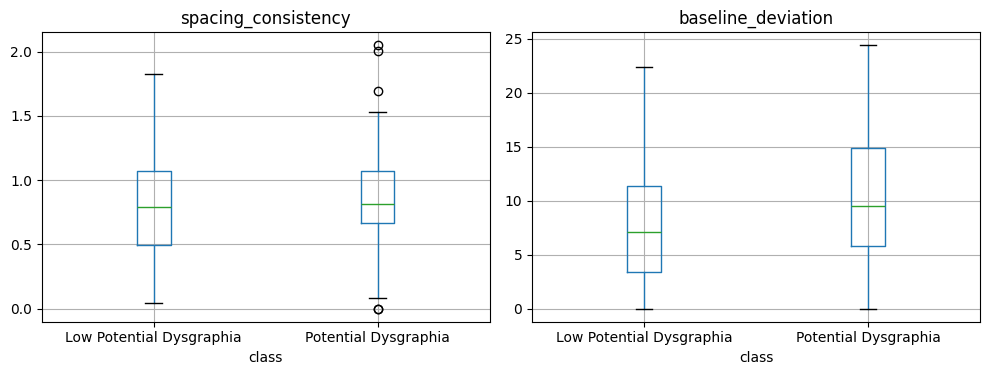

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
indicators_df.boxplot(column="spacing_consistency", by="class", ax=ax[0])
indicators_df.boxplot(column="baseline_deviation", by="class", ax=ax[1])
plt.suptitle("")
plt.tight_layout()
plt.show()

## Feature engineering summary (Malaysian PDM)
We built two interpretable indicators from the cleaned handwriting images. The spacing
consistency score uses connected component analysis to find individual strokes on each
line and measures how evenly spaced they are, and the baseline deviation score fits a
straight line through the bottom of those strokes and measures how far the writing
drifts from it. Across the dataset, the Potential Dysgraphia group showed higher average
scores on both indicators, which lines up with what we would expect. That said, this is a
small sample and both distributions overlap a fair amount between classes, so on their
own these scores are not strong enough to separate the two groups, they are meant to sit
alongside the CNN prediction as an explanation rather than replace it. A small number of
samples came back with missing scores because too few strokes were detected on a line to
measure spacing or fit a baseline, and we would flag those cases for a manual check rather
than silently dropping them.